In [250]:
print("Hello, World!")

Hello, World!


In [251]:
from research_and_analysts.utils.model_loader import ModelLoader

In [252]:
model_loader = ModelLoader()


{"level": "info", "timestamp": "2026-07-14T22:03:02.878171Z", "event": "Initializing ApiKeyManager"}
{"level": "info", "timestamp": "2026-07-14T22:03:02.884128Z", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"level": "info", "timestamp": "2026-07-14T22:03:02.899943Z", "event": "GOOGLE_API_KEY loaded successfully from environment"}


{"level": "info", "timestamp": "2026-07-14T22:03:02.900664Z", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "/Users/kjaggav1/Library/CloudStorage/OneDrive-JCPenney/myworkspace/practice/LLMOPS/automated-research-report/research_and_analysts/config/configuration.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "level": "info", "timestamp": "2026-07-14T22:03:02.937187Z", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embedding_model", "retriever", "llm"], "level": "info", "timestamp": "2026-07-14T22:03:02.939029Z", "event": "YAML configuration loaded successfully"}


In [253]:
llm = model_loader.load_llm()

{"provider": "openai", "model": "gpt-4o", "level": "info", "timestamp": "2026-07-14T22:03:02.946914Z", "event": "Loading LLM"}
{"provider": "openai", "model": "gpt-4o", "level": "info", "timestamp": "2026-07-14T22:03:02.970181Z", "event": "LLM loaded successfully"}


In [254]:
llm.invoke("hi").content

'Hello! How can I assist you today?'

In [255]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [256]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [257]:
class Analyst(BaseModel):
    name: str = Field(..., description="Name of the analyst")
    role: str = Field(..., description="Role of the analyst in the context of the topic")
    affiliation: str = Field(..., description="Primary affiliation of the analyst")
    description: str = Field(..., description="Description of the analyst focus, concerns, and motives.")

    @property
    def persona(self) -> str:
        return f"{self.name} is a {self.role} at {self.affiliation}. {self.description}"

In [258]:
Analyst(
    name="John Doe",
    role="Data Analyst",
    affiliation="XYZ Corp",
    description="Focuses on data-driven decision making and business intelligence."
)

Analyst(name='John Doe', role='Data Analyst', affiliation='XYZ Corp', description='Focuses on data-driven decision making and business intelligence.')

In [259]:
analyst = Analyst(
    name="Jane Smith",
    role="Health specialist",
    affiliation="ABC healthcare",
    description="Specializes in healthcare data analysis."
)

In [260]:
analyst.name

'Jane Smith'

In [261]:
analyst.persona

'Jane Smith is a Health specialist at ABC healthcare. Specializes in healthcare data analysis.'

In [262]:
class Perspective(BaseModel):
    analysts: List[Analyst] = Field(..., description="List of analysts providing their perspectives")

In [263]:
class GenerateAnalystsState(TypedDict):
    topic: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]
    

In [264]:
GenerateAnalystsState(
    topic= "finance",
    max_analysts= 5,
    human_analyst_feedback= "The analysts should focus on market trends and investment strategies.",
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'The analysts should focus on market trends and investment strategies.'}

In [265]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [266]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [267]:
def create_analyst(state: GenerateAnalystsState):
    """
    It is creating my analyst
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback", "")

    structured_llm = llm.with_structured_output(Perspective)

    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
    )

    analysts = structured_llm.invoke(
        [SystemMessage(content=system_messages)] + [HumanMessage(content="Generate the set of analysts.")]
    )

    return {"analysts": analysts.analysts}

In [268]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

{'analysts': [Analyst(name='Dr. Emily Chen', role='Public Health Specialist', affiliation='World Health Organization', description='Dr. Emily Chen focuses on global health trends and the impact of public health policies on population health outcomes. Her primary concern is understanding how health policies can be optimized to improve access to healthcare services and reduce health disparities across different regions. She is motivated by the need to create equitable health systems that can respond effectively to both chronic and emerging health challenges.'),
  Analyst(name='Dr. Raj Patel', role='Healthcare Technology Innovator', affiliation='HealthTech Innovations Inc.', description='Dr. Raj Patel is dedicated to exploring the intersection of technology and healthcare. His focus is on how digital health tools, such as telemedicine and AI-driven diagnostics, can transform patient care and improve health outcomes. He is particularly interested in the potential of technology to enhance h

In [269]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [270]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [271]:
from IPython.display import Image, display

First Workflow

In [272]:
builder = StateGraph(GenerateAnalystsState)

In [273]:
builder.add_node("human_feedback", human_feedback)
builder.add_node("create_analyst", create_analyst)

In [274]:
builder.add_edge(START, "create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges(
    "human_feedback",
    should_continue,
    {
        "create_analyst": "create_analyst",
        END: END
    }
)

In [275]:
memory = MemorySaver()

In [276]:
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

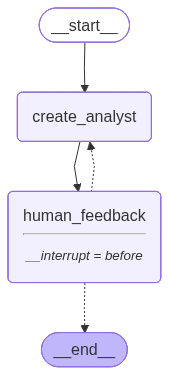

In [277]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [278]:
topic = "the benefits of adopting Langgraph as an agent framework"
thread = {"configurable": {"thread_id": 1}}
max_analysts = 4



In [279]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Studies
Role: AI Framework Researcher
Description: Dr. Chen focuses on the technical advancements and innovations in AI frameworks. She is particularly interested in how Langgraph enhances agent communication and decision-making processes, and how these improvements can lead to more efficient and intelligent AI systems.
--------------------------------------------------
Name: Michael Thompson
Affiliation: Tech Solutions Inc.
Role: Enterprise Technology Consultant
Description: Michael advises large enterprises on technology adoption. His primary concern is how Langgraph can be integrated into existing systems to improve operational efficiency and reduce costs. He evaluates the framework's scalability and its potential to streamline business processes.
--------------------------------------------------
Name: Sophia Martinez
Affiliation: Global AI Ethics Consortium
Role: Ethics and Compliance Officer
Description: Sophia is dedicat

In [280]:
state = graph.get_state(thread)

In [281]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Researcher', affiliation='Institute of Advanced AI Studies', description='Dr. Chen focuses on the technical advancements and innovations in AI frameworks. She is particularly interested in how Langgraph enhances agent communication and decision-making processes, and how these improvements can lead to more efficient and intelligent AI systems.'), Analyst(name='Michael Thompson', role='Enterprise Technology Consultant', affiliation='Tech Solutions Inc.', description="Michael advises large enterprises on technology adoption. His primary concern is how Langgraph can be integrated into existing systems to improve operational efficiency and reduce costs. He evaluates the framework's scalability and its potential to streamline business processes."), Analyst(name='Sophia Martinez', role='Ethics and Compliance Officer', affi

In [282]:
state.next

('human_feedback',)

In [283]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17fcfc-e9bd-676c-8001-799324784e9d'}}

In [284]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f17fcfc-c350-6836-bfff-261ff36595e7': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-07-14T22:03:08.618138+00:00\xa2id\xd9$1f17fcfc-c350-6836-bfff-261ff36595e7\xb0channel_versions\x81\xa9__start__\xd9400000000000000000000000000000001.0.19976082018944386\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f17fcfc-c353-627a-8000-26ea2b0926b0': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-07-14T22:03:08.619217+00:00\xa2id\xd9$1f17fcfc-c353-627a-8000-26ea2b0926b0\xb0channel_versions\x84\xa9__start__\xd9400000000000000000000000000000002.0.35784303693317987\xa5topic\xd9400000000000000000000000000000002.0.35784303693317987\xacmax_analysts\xd9400000000000000000000000000000002.0.35784303693317987\xb8branch:to:create_analyst\xd9400000000000000000000000000000002.0.35784303693317987\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start

In [285]:
graph.update_state(
    thread,
    {"human_analyst_feedback": "These analysts are great! Please generate 2 more analysts with a focus on technical implementation and use cases."},
    as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17fcfc-ea67-617c-8002-6abbe5c19fc2'}}

In [286]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Studies
Role: AI Framework Researcher
Description: Dr. Chen focuses on the technical advancements and innovations in AI frameworks. She is particularly interested in how Langgraph enhances agent communication and decision-making processes, and how these improvements can lead to more efficient and intelligent AI systems.
--------------------------------------------------
Name: Michael Thompson
Affiliation: Tech Solutions Inc.
Role: Enterprise Technology Consultant
Description: Michael advises large enterprises on technology adoption. His primary concern is how Langgraph can be integrated into existing systems to improve operational efficiency and reduce costs. He evaluates the framework's scalability and its potential to streamline business processes.
--------------------------------------------------
Name: Sophia Martinez
Affiliation: Global AI Ethics Consortium
Role: Ethics and Compliance Officer
Description: Sophia is dedicat

In [287]:
state = graph.get_state(thread)

In [288]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'These analysts are great! Please generate 2 more analysts with a focus on technical implementation and use cases.', 'analysts': [Analyst(name='Dr. Emily Chen', role='Technical Implementation Specialist', affiliation='Tech Innovations Lab', description='Dr. Chen focuses on the technical aspects of adopting Langgraph as an agent framework. She is particularly interested in how Langgraph can be integrated into existing systems, the challenges of implementation, and the technical benefits it offers, such as scalability and efficiency improvements.'), Analyst(name='Raj Patel', role='Use Case Analyst', affiliation='FutureTech Consulting', description='Raj Patel analyzes various use cases for Langgraph, exploring how different industries can leverage this framework to enhance their operations. He is interested in practical applications, from customer service

In [289]:
state.next

('human_feedback',)

In [290]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'These analysts are great! Please generate 2 more analysts with a focus on technical implementation and use cases.',
 'analysts': [Analyst(name='Dr. Emily Chen', role='Technical Implementation Specialist', affiliation='Tech Innovations Lab', description='Dr. Chen focuses on the technical aspects of adopting Langgraph as an agent framework. She is particularly interested in how Langgraph can be integrated into existing systems, the challenges of implementation, and the technical benefits it offers, such as scalability and efficiency improvements.'),
  Analyst(name='Raj Patel', role='Use Case Analyst', affiliation='FutureTech Consulting', description='Raj Patel analyzes various use cases for Langgraph, exploring how different industries can leverage this framework to enhance their operations. He is interested in practical applications, from customer service automation to c

In [291]:
further_feedack = ""

In [292]:
state = graph.get_state(thread)

cfg = state.config

In [293]:
graph.update_state(cfg, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17fcfd-0d95-605e-8006-b25bba7427be'}}

In [294]:
final_state = graph.get_state(thread)
print(final_state.next)

()


In [295]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="Langgraph").load()
print(docs[0].page_content[:500])  # Print the first 500 characters of the content

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="The benefits of adopting AWS Cloud").load()
print(docs[0].page_content[:500])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [297]:
from langchain_community.utilities import WikipediaAPIWrapper
wiki = WikipediaAPIWrapper(doc_content_chars_max=500)
docs = wiki.run(f"soccer")
print(docs)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

##Second Workflow

In [298]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [299]:
import os
from dotenv import load_dotenv
load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [300]:
tavily_search = TavilySearchResults(api_key=tavily_api_key)

In [301]:
tavily_search.invoke("Soccer benefits and history")

[{'title': 'Cheltenham Sports',
  'url': 'https://www.cheltenhamsports.org/content/34767/What-Are-the-Physical-Benefits-of-Playing-Soccer',
  'content': "|  |  |\n --- |\n|  | select |\n\n# What Are the Physical Benefits of Playing Soccer?\n\nSeptember 11, 2024\n\nSoccer, or football as it’s called in many parts of the world, is a sport with a rich history, captivating billions of fans across the globe. It's more than just a competitive game; it’s a full-body workout that provides numerous physical and mental health benefits. Whether you’re playing at an amateur level in a local league or on a professional stage, soccer promotes health and well-being in a variety of ways. In this article, we’ll explore the physical benefits of playing soccer, dive into things to consider while playing, and discuss the mental and social advantages of the sport. [...] ## Conclusion\n\nThe physical benefits of playing soccer are numerous and undeniable. From improved cardiovascular health and increased mu

In [302]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="Meditation and pranayama benefits").load()
print(docs[0].page_content[:500])  # Print the first 500 characters

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [303]:
import operator
from typing import Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int
    context: Annotated[list, operator.add]
    analyst: Analyst
    interview: str
    sections: list

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="The search query to be used for retrieving relevant information.")


In [304]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [305]:
print(analyst.persona)

Liam O'Connor is a Business Strategy Consultant at Strategic Insights Group. Liam O'Connor evaluates the strategic business benefits of adopting Langgraph. He is interested in how this framework can drive innovation, improve operational efficiency, and create new business opportunities, ultimately contributing to a company's competitive advantage.


In [306]:
question_instructions.format(goals = analyst.persona)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Liam O\'Connor is a Business Strategy Consultant at Strategic Insights Group. Liam O\'Connor evaluates the strategic business benefits of adopting Langgraph. He is interested in how this framework can drive innovation, improve operational efficiency, and create new business opportunities, ultimately contributing to a company\'s competitive advantage.\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the i

In [307]:
def generation_question(state: InterviewState):
    """Node to generate the questions"""

    # get state
    analyst = state["analyst"]
    messages = state["messages"]

    #generate the question
    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)] + messages)

    # return the question
    return {"messages": [question]}



In [308]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [309]:
result = generation_question(state)

In [310]:
result

{'messages': [AIMessage(content="Hello, my name is Alex Carter, and I'm an analyst keen on understanding the strategic business benefits of adopting Langgraph. I'm particularly interested in how this framework can drive innovation, improve operational efficiency, and create new business opportunities. \n\nLiam, could you start by explaining what Langgraph is and why it's considered a valuable tool for businesses looking to gain a competitive advantage?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 226, 'total_tokens': 300, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549', 'id': 'chatcmpl-E1fY1j2Ptdbl7mr3YW7oUxoqzVUXW', 'service_tier': 'default', 'finish_reason': '

In [311]:
print(result["messages"][0].content)

Hello, my name is Alex Carter, and I'm an analyst keen on understanding the strategic business benefits of adopting Langgraph. I'm particularly interested in how this framework can drive innovation, improve operational efficiency, and create new business opportunities. 

Liam, could you start by explaining what Langgraph is and why it's considered a valuable tool for businesses looking to gain a competitive advantage?


In [312]:
from langchain_core.messages import get_buffer_string

In [313]:
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [314]:
def search_web(state: InterviewState):
    """Retrieve data from web"""
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions] + state["messages"])

    # Search
    search_docs = tavily_search.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [315]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Johnson, and I'm an analyst interested in learning more about healthcare data analysis. I'm excited to speak with you, Jane, about your expertise in this field. To start, could you share an example of a surprising insight you've discovered through healthcare data analysis that had a significant impact on patient care?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 186, 'total_tokens': 250, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_9badba931f', 'id': 'chatcmpl-DzqDwYnQFDJhVdFqReXUSU7UNURNM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f48b3-1f6a-7783-b9bf-3027b11bc3a6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 186, 'output_tokens': 64, 'total_tokens': 250, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [316]:
result = search_web(state)

In [317]:
print(result["context"][0])

<Document href="https://www.park.edu/blog/data-analytics-in-healthcare-transforming-patient-care-delivery"/>
Data-driven insights can also help reduce unnecessary medical procedures and hospital readmissions, both of which contribute to rising healthcare costs. By identifying patterns in patient data, healthcare organizations can focus on improving processes and reducing waste, leading to more efficient and cost-effective care.

### Preventive Care

Preventive care is a key focus in modern healthcare, and data analytics plays a critical role in its advancement. By analyzing large datasets, healthcare providers can identify risk factors and predict which patients are most likely to develop certain conditions. This allows for earlier interventions that can prevent the onset of chronic diseases, ultimately reducing healthcare costs and improving patient quality of life. [...] ## What Is Healthcare Data Analytics?

Healthcare data analytics is the systematic analysis of health data to impr

In [324]:
import wikipedia
wikipedia.set_user_agent("my-research-bot/1.0 (your-email@example.com)")

from langchain_community.utilities import WikipediaAPIWrapper

def search_wikipedia(state: InterviewState):
    """Retrieve data from Wikipedia"""
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions] + state["messages"])

    print("*******************************")
    print(search_query)

    wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=4000)
    try:
        wiki_results = wiki.run(search_query.search_query)
    except Exception:
        wiki_results = "No results available."

    formatted_wiki_docs = f'<Document href="wikipedia"/>\n{wiki_results}\n</Document>'
    return {"context": [formatted_wiki_docs]}


In [325]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the benefits of pranayama for health. I'm particularly keen on how this framework can drive innovation and support health initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain why meditation and pranayama was significant?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [326]:
result = search_wikipedia(state)

*******************************
search_query='benefits of pranayama for health and innovation in health initiatives'


In [328]:
from langchain_community.utilities import WikipediaAPIWrapper

wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=4000)
docs = wiki.load("Meditation and pranayama benefits")
print(docs[0].page_content[:500])

Pranayama (Sanskrit: प्राणायाम, "Prāṇāyāma") is the yogic practice of controlling the breath in Hinduism. It is described in Hindu texts such as the Upanishads and the Bhagavad Gita; in the Yoga Sutras of Patanjali, it is one of the eight limbs of yoga. In classical yoga, the breath is associated with the life energy or prana. Later, in Hatha yoga texts, it meant the complete suspension of breathing. The pranayama practices in modern yoga as exercise, such as in Ashtanga (vinyasa) yoga, differ r


In [329]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [330]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [331]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [332]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [333]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [334]:
def generate_answer(state: InterviewState):

    """ Node to answer a question based upon the context and the conversation history"""
    # get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # generate the answer
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)] + messages)

    answer.name = "expert"

    return {"messages": [answer]}

In [335]:
def route_messages(state: InterviewState,
                   name: str = "expert"):
    
    """ Route between question and answer nodes based upon the name of the message sender"""
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get("max_num_turns", 2)

    # Check the number of expert answers
    num_responses = len([msg for msg in messages if isinstance(msg, AIMessage) and msg.name == name])

    # End if the number of expert answers is greater than or equal to the max number of turns
    if num_responses >= max_num_turns:
        return "save_interview"
    
    last_question = messages[-2]

    if "Thank you so much for your help!" in last_question.content:
        return "save_interview"
    
    return "ask_question"



In [336]:
def save_interview(state: InterviewState):
    """Save the interview"""

    # get state
    messages = state["messages"]

    # get the last message
    interview = get_buffer_string(messages)

    # return the interview
    return {"interview": interview}


In [337]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [338]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

In [339]:
interview_builder = StateGraph(InterviewState)

In [340]:
interview_builder.add_node("generate_question", generation_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("generate_answer", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

In [341]:
interview_builder.add_edge(START, "generate_question")
interview_builder.add_edge("generate_question", "search_web")
interview_builder.add_edge("generate_question", "search_wikipedia")
interview_builder.add_edge("search_web", "generate_answer")
interview_builder.add_edge("search_wikipedia", "generate_answer")
interview_builder.add_conditional_edges("generate_answer", route_messages, {"ask_question": "generate_question", "save_interview": "save_interview"})
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

In [342]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

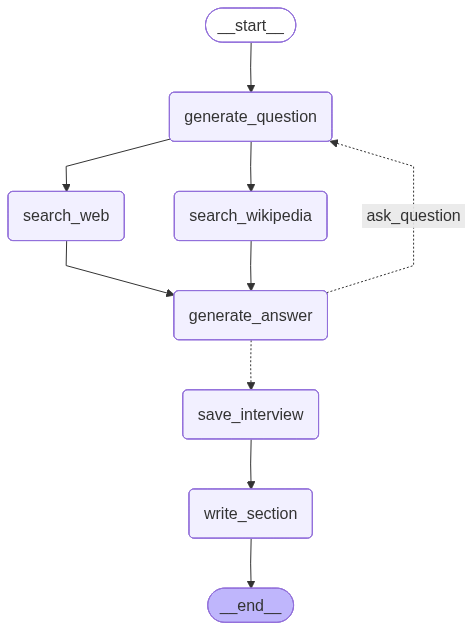

In [343]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [344]:
analyst

Analyst(name="Liam O'Connor", role='Business Strategy Consultant', affiliation='Strategic Insights Group', description="Liam O'Connor evaluates the strategic business benefits of adopting Langgraph. He is interested in how this framework can drive innovation, improve operational efficiency, and create new business opportunities, ultimately contributing to a company's competitive advantage.")

In [345]:
analyst.persona

"Liam O'Connor is a Business Strategy Consultant at Strategic Insights Group. Liam O'Connor evaluates the strategic business benefits of adopting Langgraph. He is interested in how this framework can drive innovation, improve operational efficiency, and create new business opportunities, ultimately contributing to a company's competitive advantage."

In [346]:
thread = {"configurable": {"thread_id": "1"}}

In [347]:
from IPython.display import Markdown

In [348]:
messages = [HumanMessage("So you said you were writing an article on health?")]

In [349]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

*******************************
search_query='examples of Langgraph implementation in businesses for innovation and competitive advantage'
*******************************
search_query='Langgraph features driving innovation in businesses'


In [350]:
Markdown(interview['sections'][0])

## LangGraph: A Strategic Catalyst for Business Innovation and Efficiency

### Summary

In the rapidly evolving landscape of AI-driven business solutions, LangGraph emerges as a transformative framework that offers significant strategic benefits. By adopting LangGraph, companies can drive innovation, enhance operational efficiency, and unlock new business opportunities, thereby gaining a competitive edge. This report delves into the strategic advantages of LangGraph, highlighting its novel features and real-world applications.

LangGraph's graph-based architecture is a key differentiator, allowing businesses to design workflows that are more flexible and adaptable than traditional linear processes. This flexibility is crucial for handling complex business scenarios, enabling sophisticated error handling, context retention, and seamless integration with existing systems [1]. The framework's ability to support long-running, state-aware agents ensures that workflows can pause and resume without losing context, which is essential for maintaining operational continuity [2].

One of the most compelling aspects of LangGraph is its capacity to enhance innovation through agentic workflows. By leveraging multiple AI agents, businesses can automate and optimize various processes, from competitive research to customer service transformation. For instance, LinkedIn has utilized LangGraph to streamline its hiring process, freeing up human recruiters to focus on strategic tasks [3]. Similarly, an e-commerce giant has transformed its customer service operations, achieving higher efficiency and customer satisfaction [4].

LangGraph also offers practical gains in terms of time and cost savings. Its modular design allows for the breakdown of complex processes into manageable components, facilitating scalability and reducing errors [5]. The integration of LangGraph with vector databases and advanced memory management further enhances its operational efficiency, providing long-term financial benefits [6].

Moreover, LangGraph's open-source nature and compatibility with various large language models (LLMs) eliminate vendor lock-in, offering businesses the flexibility to choose the best tools for their needs [7]. This adaptability is crucial for future-proofing AI initiatives and ensuring that they remain relevant as technology evolves.

In conclusion, LangGraph represents a strategic asset for businesses looking to harness the power of AI. Its innovative features and proven real-world applications make it an invaluable tool for driving business success in today's competitive environment.

### Sources
[1] https://sparkco.ai/blog/mastering-langgraph-workflow-orchestration-in-enterprises  
[2] https://www.truefoundry.com/blog/langchain-vs-langgraph  
[3] https://www.langchain.com/blog/is-langgraph-used-in-production  
[4] https://www.rapidinnovation.io/post/ai-agents-in-langgraph  
[5] https://medium.com/@garima_yadav/real-world-applications-and-case-studies-with-langgraph-from-theory-to-practice-7a6ffd2e8e1b  
[6] https://aerospike.com/blog/langgraph-production-latency-replay-scale  
[7] https://www.linkedin.com/posts/pavan-belagatti_i-dont-know-what-you-guys-are-using-but-activity-7411431711873626112-l_IT  

Third Workflow

In [351]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator

class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

In [352]:
from langgraph.types import Send

In [353]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]

In [354]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [355]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [356]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [357]:
def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [358]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [359]:
def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [360]:
# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

In [361]:
memory = MemorySaver()

In [362]:
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

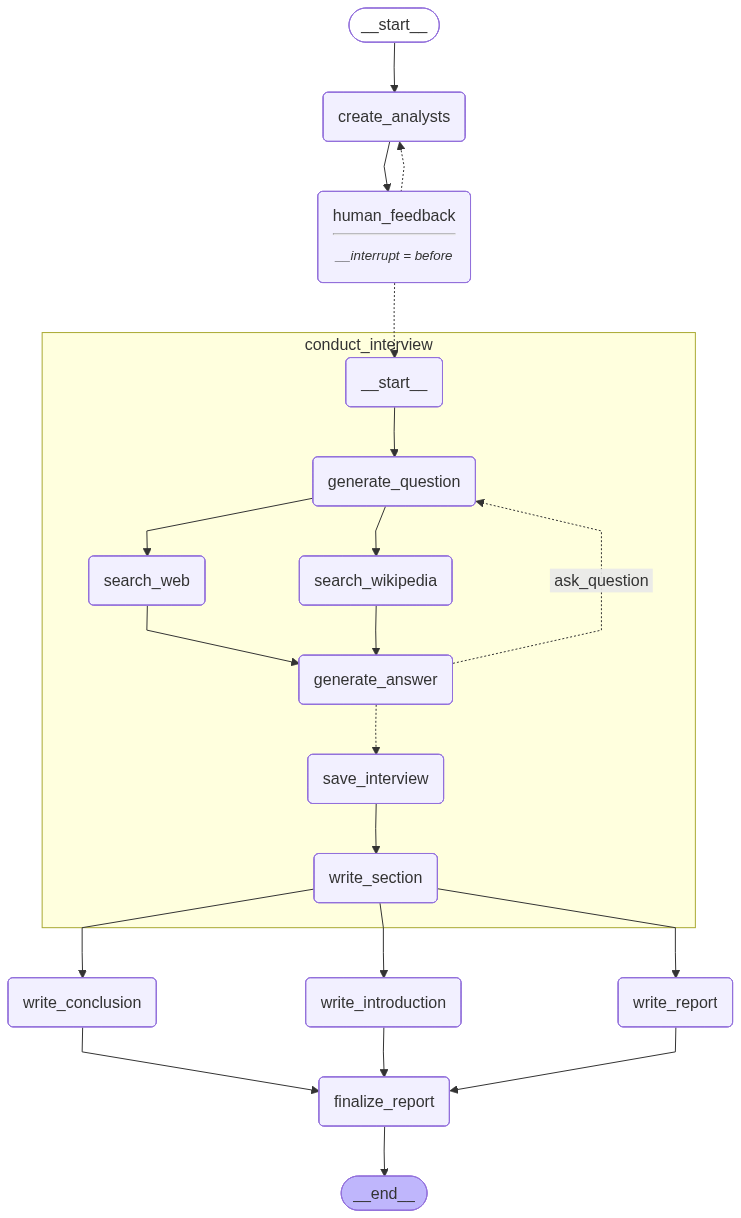

In [363]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [364]:
max_analysts = 3

In [365]:
topic = "How can pranayama and meditation enhance mental well-being?"

In [366]:
thread = {"configurable": {"thread_id": "1"}}

In [367]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Anjali Mehta
Affiliation: Mindful Living Institute
Role: Clinical Psychologist
Description: Dr. Mehta focuses on the psychological benefits of pranayama and meditation, particularly how these practices can reduce anxiety and depression. She is interested in integrating these techniques into traditional therapeutic practices to enhance mental health outcomes.
--------------------------------------------------
Name: Rajesh Kumar
Affiliation: Harmony Yoga Center
Role: Yoga and Meditation Instructor
Description: Rajesh Kumar is dedicated to exploring the physiological impacts of pranayama and meditation on the brain and body. He emphasizes the importance of breath control and mindfulness in achieving mental clarity and emotional balance, and advocates for their inclusion in daily routines for stress management.
--------------------------------------------------
Name: Dr. Emily Chen
Affiliation: NeuroWellness Research Lab
Role: Neuroscientist
Description: Dr. Chen investigates the

In [368]:
graph.update_state(thread, {"human_analyst_feedback":"along with the mental health being also give advantanges and benefits"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17fd29-446b-6106-8002-f6ad6930b28d'}}

In [369]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Anjali Mehta
Affiliation: Mindful Living Institute
Role: Clinical Psychologist
Description: Dr. Mehta focuses on the psychological benefits of pranayama and meditation, particularly how these practices can reduce anxiety and depression. She is interested in integrating these techniques into traditional therapeutic practices to enhance mental health outcomes.
--------------------------------------------------
Name: Rajesh Kumar
Affiliation: Harmony Yoga Center
Role: Yoga and Meditation Instructor
Description: Rajesh Kumar is dedicated to exploring the physiological impacts of pranayama and meditation on the brain and body. He emphasizes the importance of breath control and mindfulness in achieving mental clarity and emotional balance, and advocates for their inclusion in daily routines for stress management.
--------------------------------------------------
Name: Dr. Emily Chen
Affiliation: NeuroWellness Research Lab
Role: Neuroscientist
Description: Dr. Chen investigates the

In [370]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17fd29-a350-61f8-8006-b86f23652b7b'}}

In [371]:
graph.get_state(thread).next

('conduct_interview', 'conduct_interview', 'conduct_interview')

In [372]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

*******************************
search_query='neurological impacts of pranayama and meditation on cognitive functions like attention and memory'
*******************************
search_query='mechanisms pranayama meditation reduce anxiety depression brain chemistry emotional regulation'
*******************************
search_query='examples of pranayama and meditation improving mental health'
*******************************
search_query='case study pranayama meditation brain wave patterns cognitive function improvement'
*******************************
search_query='case study pranayama meditation anxiety depression brain chemistry emotional regulation'
*******************************
search_query='case study pranayama meditation mental health improvement'
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_introduction
--Node--
write_conclusion
--Node--
write_report
--Node--
finalize_report


In [373]:
from IPython.display import Markdown

In [374]:
final_state = graph.get_state(thread)

In [375]:
report = final_state.values.get('final_report')

In [376]:
Markdown(report)

# Enhancing Mental Well-being Through Pranayama and Meditation

## Introduction

In an era where mental health challenges such as anxiety, depression, and chronic stress are increasingly prevalent, the exploration of complementary therapies like pranayama and meditation has gained momentum. Rooted in ancient yogic traditions, these practices offer profound psychological benefits by influencing brain chemistry and enhancing emotional regulation. This report delves into the psychological and neurological impacts of pranayama and meditation, highlighting their ability to modulate brain activity, promote neuroplasticity, and improve cognitive functions. By integrating these practices into daily routines, individuals can achieve holistic well-being, benefiting both mental and physical health.

---



Pranayama and meditation, rooted in ancient yogic traditions, are gaining recognition as effective complementary therapies for enhancing mental well-being. These practices offer promising psychological benefits by influencing brain chemistry and improving emotional regulation, making them valuable tools in managing mental health disorders such as anxiety, depression, and chronic stress.

Pranayama, a discipline involving controlled breathing techniques, has been shown to significantly reduce symptoms of anxiety and depression, enhance stress resilience, and improve emotional regulation [1][2]. The neurophysiological mechanisms through which pranayama exerts its effects include modulation of the hypothalamic-pituitary-adrenal (HPA) axis, increased vagal tone, and improved autonomic balance. These changes promote activity in brain regions involved in emotional processing, such as the amygdala, anterior cingulate cortex (ACC), anterior insula, and prefrontal cortex [1][3]. Functional MRI studies have demonstrated reduced functional connectivity in these areas, correlating with decreased anxiety and negative affect [1][4]. Additionally, pranayama enhances parasympathetic nervous system activity, which helps regulate stress hormones and increases gamma-aminobutyric acid (GABA) inhibition, reducing amygdala hyperactivity [2][5].

Meditation, another critical component of yoga, involves training attention and awareness to achieve a mentally clear and emotionally calm state. It has been shown to induce high-amplitude gamma synchrony in EEG recordings, particularly in the parieto-temporal and midfrontal cortical areas, which is associated with improved attention modulation and memory tasks [3]. Long-term meditation practice is linked to distinct patterns of brain activity, particularly in the default mode network, crucial for attention and emotion regulation [3].

The integration of pranayama and meditation into daily routines offers a holistic approach to mental health, with the potential to alter brain chemistry and improve emotional regulation. These practices provide a natural, scientifically backed method for managing anxiety and depression, paving the way for future research into their mechanisms and clinical applications. They not only provide immediate benefits in terms of stress reduction and mental clarity but also offer long-term neuroprotective effects, potentially mitigating age-related cognitive decline [4].

Furthermore, specific pranayama techniques, such as Nadi shodhana and Ujjayi, have been shown to improve cognitive functions in healthy individuals, enhancing attention and memory while reducing anxiety [2]. SKY Breath Meditation, a specific form of pranayama, has been highlighted as a powerful mental health tool, offering numerous mental health benefits, including enhanced optimism, decreased depression, increased self-esteem, and improved relationships [4].

In conclusion, pranayama and meditation offer a holistic approach to enhancing overall well-being. These practices not only improve mental health but also contribute to physical health, making them valuable tools for individuals seeking a balanced and healthy lifestyle. Their accessibility and cost-effectiveness make them attractive alternatives or complementary therapies for mental health management, free from side effects and easily integrated into daily routines [5].


---

## Conclusion

Pranayama and meditation, deeply rooted in ancient traditions, offer a promising, holistic approach to enhancing mental well-being. By influencing brain chemistry and improving emotional regulation, these practices provide a natural, side-effect-free method for managing anxiety and depression. The neurophysiological benefits, such as increased vagal tone and improved autonomic balance, underscore their potential in stress resilience and emotional processing. Furthermore, the integration of pranayama and meditation into daily routines can enhance cognitive functions, promote neuroplasticity, and offer long-term neuroprotective effects. As research continues to validate these benefits, pranayama and meditation emerge as accessible, cost-effective tools for mental health management and overall well-being.

## Sources
[1] https://www.academia.edu/145802217/Effect_of_pranayama_on_mental_health_A_review_of_evidence_and_implication  
[2] https://yogatherapyassociates.com/yoga-for-anxiety  
[3] https://www.frontiersin.org/journals/psychiatry/articles/10.3389/fpsyt.2020.00467/full  
[4] https://www.psypost.org/four-weeks-of-pranayama-breathing-exercises-reduces-anxiety-and-negative-affect-and-is-linked-to-changes-in-the-brain  
[5] https://www.ijcep.org/index.php/ijcep/article/view/804  
[6] https://ijip.in/articles/memory-and-neuroplasticity  
[7] https://juniperpublishers.com/jyp/pdf/JYP.MS.ID.555838.pdf  
[8] https://pmc.ncbi.nlm.nih.gov/articles/PMC7735501  
[9] https://digitalcommons.odu.edu/cgi/viewcontent.cgi?article=1605&context=ots_masters_projects  
[10] https://en.wikipedia.org/wiki/Meditation  
[11] https://pmc.ncbi.nlm.nih.gov/articles/PMC9547124  
[12] https://www.artofliving.org/us-en/blog/pranayama-exercises-the-secret-to-better-mental-health-is-your-brea